In [1]:
import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
parent_dir = os.path.dirname(os.environ["GTE_DIR"].replace("Glaciation_time_estimator",""))
GTE_DIR=os.environ["GTE_DIR"]
sys.path.insert(0, parent_dir)
from glaciation_time_estimator.data_postprocessing.Job_result_fp_generator import generate_tracking_filenames
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
from glaciation_time_estimator.auxiliary_func.chunking_data import ChunkLoader

In [2]:
config = read_config(
    os.path.join(GTE_DIR,'config_n2o.yaml'))
analyze_year=True
year=2010
glac_threshold=0.4
global global_rmse
global_rmse = config["Global_sqrt_mse"]
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
# temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
temperature_palette = ['#f1eef6','#d0d1e6','#a6bddb','#74a9cf','#2b8cbe','#045a8d']
classifiacation_palette = ['#e41a1c', '#377eb8', "#4daf4a"]
temperature_palette = ['#eff3ff','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']

In [3]:
data_chunks = ChunkLoader([2010],config)

In [4]:
cloud_data = data_chunks.cloud_chunk
cloud_data=cloud_data[~cloud_data.is_large_pix_cloud]
cloud_data = cloud_data[(cloud_data.avg_lat >30) | (cloud_data.avg_lat<-30)]

In [5]:
temp_bins = np.linspace(235.15,273.15,39)
cloud_data["temp_bin"] = pd.cut(cloud_data["avg_ctt"],temp_bins,labels = temp_bins[:-1])

In [6]:
binned_occ_rates = cloud_data.groupby("temp_bin").is_glaciating.mean()

/tmp/ipykernel_40502/2152184233.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_occ_rates = cloud_data.groupby("temp_bin").is_glaciating.mean()


In [7]:
cloud_data["temp_bin"].value_counts()

temp_bin
258.15    302198
252.15    274306
264.15    252905
246.15    228656
263.15    220698
257.15    218786
251.15    214550
240.15    189651
245.15    189314
269.15    176785
239.15    161807
270.15    159982
268.15    104119
262.15     80723
265.15     72685
271.15     66856
259.15     62019
267.15     48739
272.15     38004
253.15     36878
256.15     33709
266.15     29659
261.15     25342
247.15     24219
241.15     22764
250.15     18305
260.15     16320
244.15     10646
255.15      7797
254.15      6990
238.15      4314
248.15      4086
242.15      3281
249.15      2861
243.15       823
237.15        57
236.15         0
235.15         0
Name: count, dtype: int64

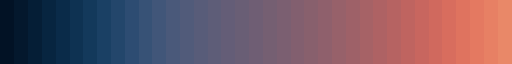

In [9]:
import cmcrameri.cm
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
# Select a continuous colormap (e.g., 'viridis')
cmap_cont_filter = cmcrameri.cm.lipari

# Number of discrete levels
levels = 37

# Sample colors evenly from the continuous map
colors_filtered_classes = cmap_cont_filter(np.linspace(0, 0.7, levels))

# Create a new discrete colormap
cmap_filtered_classes = ListedColormap(colors_filtered_classes, name='viridis_6')
cmap_filtered_classes

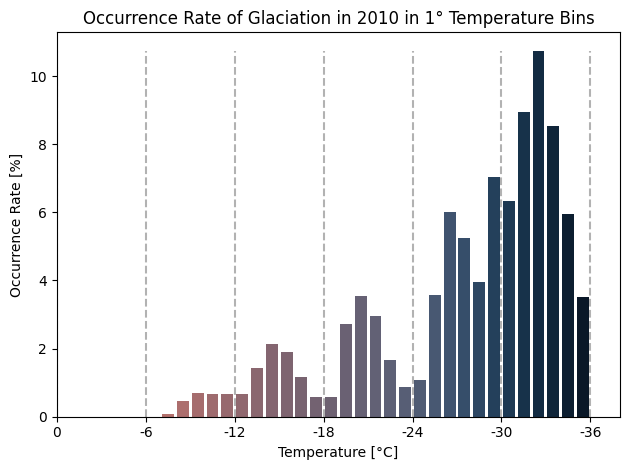

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example data
# temp_bins = np.linspace(250, 300, 11)
# binned_occ_rates = np.random.rand(10)

# Compute your x‐positions
x = 273.15 - temp_bins[1:]

fig, ax = plt.subplots()
# draw your reference lines first
ax.vlines(np.arange(0, 37, 6)-0.5,
          0,
          binned_occ_rates.max() * 100,
          linestyles="--",
          color="black",
          alpha=0.3)

# then the barplot
sns.barplot(x=x, y=binned_occ_rates * 100, ax=ax,palette=cmap_filtered_classes.colors[::-1])

# now explicitly set the ticks (no show=…)
ax.set_xticks(np.arange(0,37,6)-0.5)

# if you want custom labels (e.g. integers or formatted strings):
ax.set_xticklabels(-np.arange(0,37,6))
ax.set_title("Occurrence Rate of Glaciation in 2010 in 1° Temperature Bins")
ax.set_ylabel("Occurrence Rate [%]")
ax.set_xlabel("Temperature [°C]")
fig.tight_layout()
fig.savefig("/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Tracking_quality_evidence/1_deg_bin_occurance_rates.pdf")
plt.show()


In [13]:
cmap_filtered_classes.colors

array([[0.01137 , 0.07324 , 0.148284, 1.      ],
       [0.018046, 0.095138, 0.17697 , 1.      ],
       [0.023227, 0.119924, 0.213776, 1.      ],
       [0.030209, 0.145478, 0.251025, 1.      ],
       [0.040951, 0.171536, 0.288282, 1.      ],
       [0.056373, 0.198137, 0.325072, 1.      ],
       [0.077499, 0.225063, 0.360661, 1.      ],
       [0.105413, 0.251937, 0.393974, 1.      ],
       [0.139522, 0.277918, 0.423506, 1.      ],
       [0.178074, 0.301843, 0.447622, 1.      ],
       [0.217939, 0.322418, 0.465058, 1.      ],
       [0.256094, 0.3386  , 0.475542, 1.      ],
       [0.290422, 0.350279, 0.479979, 1.      ],
       [0.320355, 0.358086, 0.480032, 1.      ],
       [0.346516, 0.363098, 0.477353, 1.      ],
       [0.370195, 0.366362, 0.473154, 1.      ],
       [0.392637, 0.368608, 0.468151, 1.      ],
       [0.414838, 0.370329, 0.462661, 1.      ],
       [0.437471, 0.371834, 0.456836, 1.      ],
       [0.460861, 0.373274, 0.450722, 1.      ],
       [0.485169, 0.